# Data Visualization and Parsing

In [12]:
# imports
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
from skimage.color import rgb2hsv
import cv2
from skimage.morphology import closing, opening, disk, remove_small_holes, remove_small_objects


In [2]:
#load data
train_df = pd.read_csv('train.csv')
sample_df = pd.read_csv('sample_submission.csv')

print("TRAIN CSV")
print(f"Shape: {train_df.shape}")
print(train_df.head())

print("\nAMPLE SUBMISSION")
print(f"Shape: {sample_df.shape}")
print(sample_df.head())

TRAIN CSV
Shape: (81, 7)
   image_id center_card active_player   player_1_cards  player_2_cards  \
0  L1000770         y_1            p3            EMPTY     y_4;g_2;r_3   
1  L1000771         r_5            p1      y_7;y_8;g_4           EMPTY   
2  L1000772         r_9            p2      y_8;b_6;g_3  b_skip;r_0;r_3   
3  L1000773         y_8            p4     r_1;wild;g_2           EMPTY   
4  L1000774         r_4            p3  g_4;g_8;r_7;b_3         r_9;g_3   

         player_3_cards player_4_cards  
0        r_skip;y_2;b_5          EMPTY  
1               r_9;y_0          EMPTY  
2           r_6;g_2;r_9   b_draw_2;y_7  
3  draw_4;g_reverse;y_1  y_reverse;r_3  
4          wild;y_3;r_8        b_7;b_6  

AMPLE SUBMISSION
Shape: (160, 7)
   image_id center_card active_player player_1_cards player_2_cards  \
0  L1000793       EMPTY         EMPTY          EMPTY          EMPTY   
1  L1000794       EMPTY         EMPTY          EMPTY          EMPTY   
2  L1000795       EMPTY         EMPTY

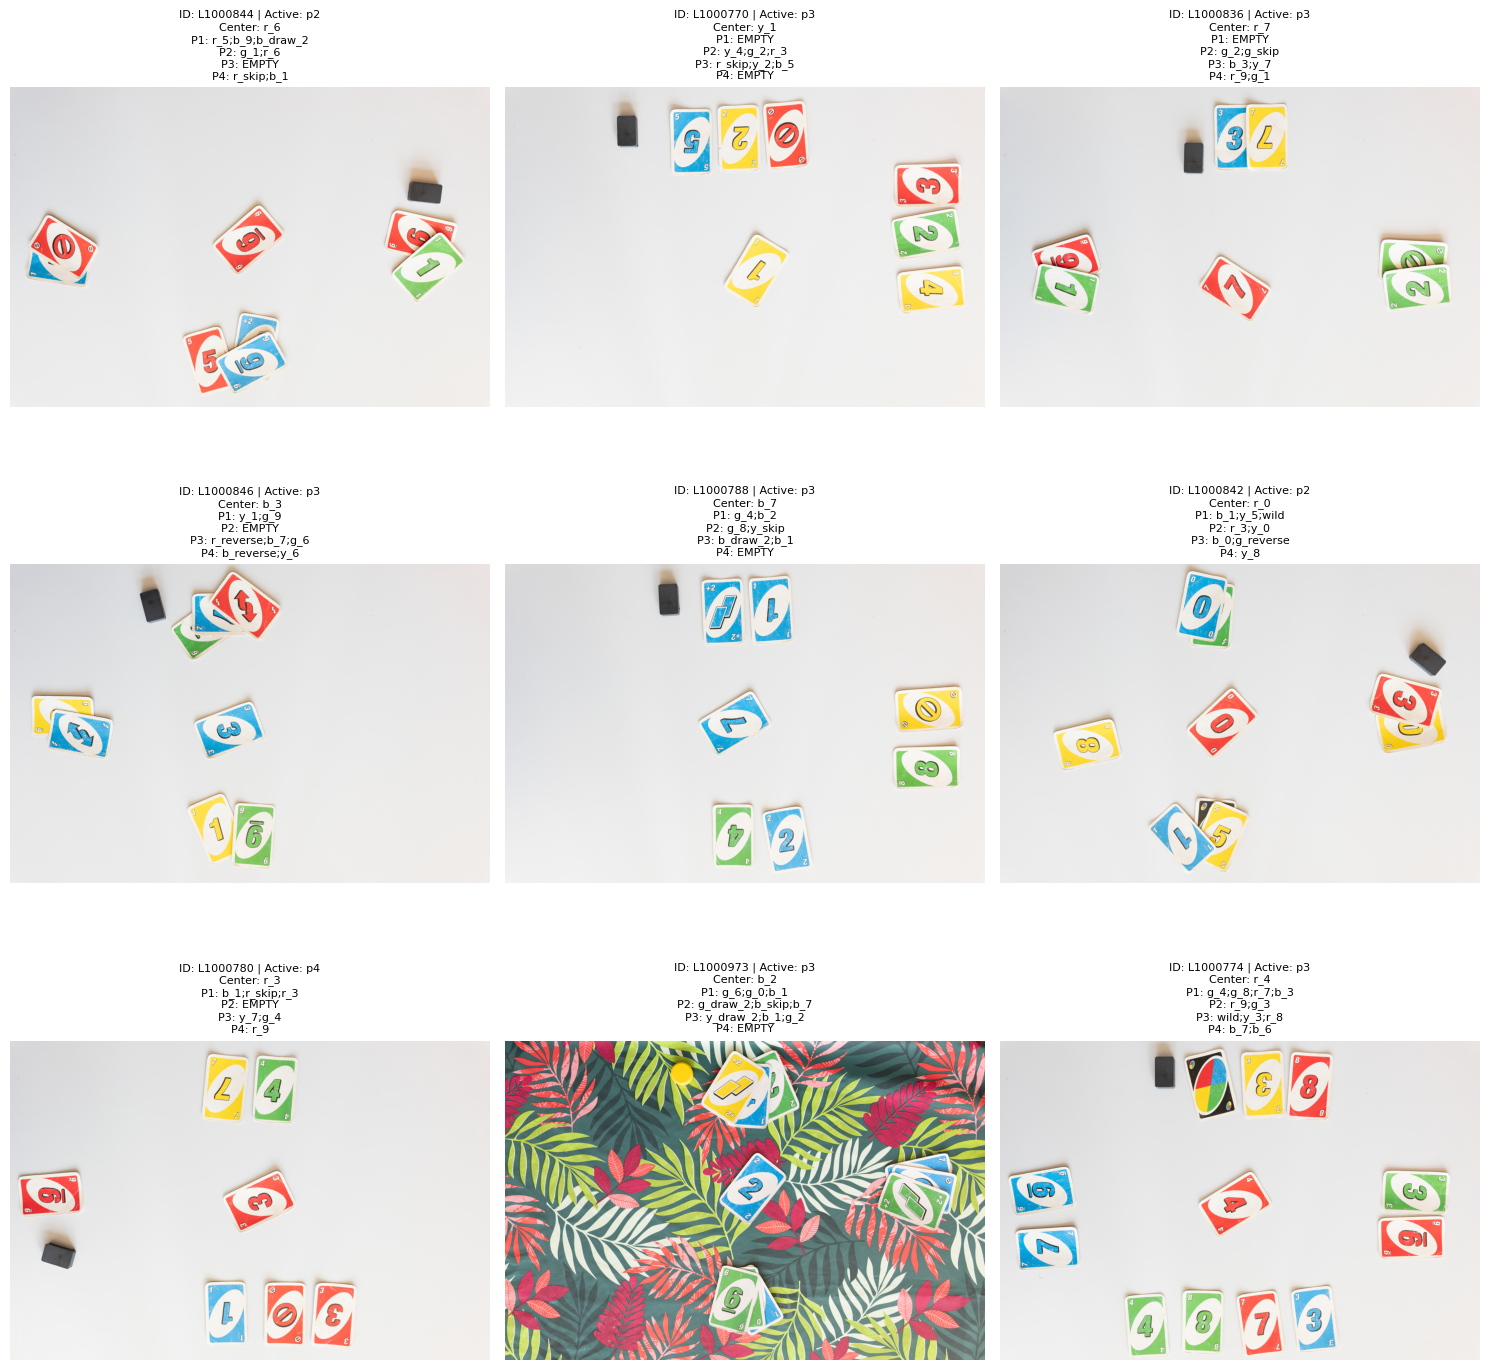

In [7]:
#visualize training images with their labels
train_image_dir = 'train_images/'

fig, axes = plt.subplots(3, 3, figsize=(15, 15))
axes = axes.flatten()

for i, (_, row) in enumerate(train_df.sample(9, random_state=42).iterrows()):
    img = Image.open(os.path.join(train_image_dir, row['image_id'] + '.jpg'))
    axes[i].imshow(img)
    title = (f"ID: {row['image_id']} | Active: {row['active_player']}\n"
             f"Center: {row['center_card']}\n"
             f"P1: {row['player_1_cards'][:20]}\n"
             f"P2: {row['player_2_cards'][:20]}\n"
             f"P3: {row['player_3_cards'][:20]}\n"
             f"P4: {row['player_4_cards'][:20]}")
    axes[i].set_title(title, fontsize=8)
    axes[i].axis('off')

plt.tight_layout()
plt.show()

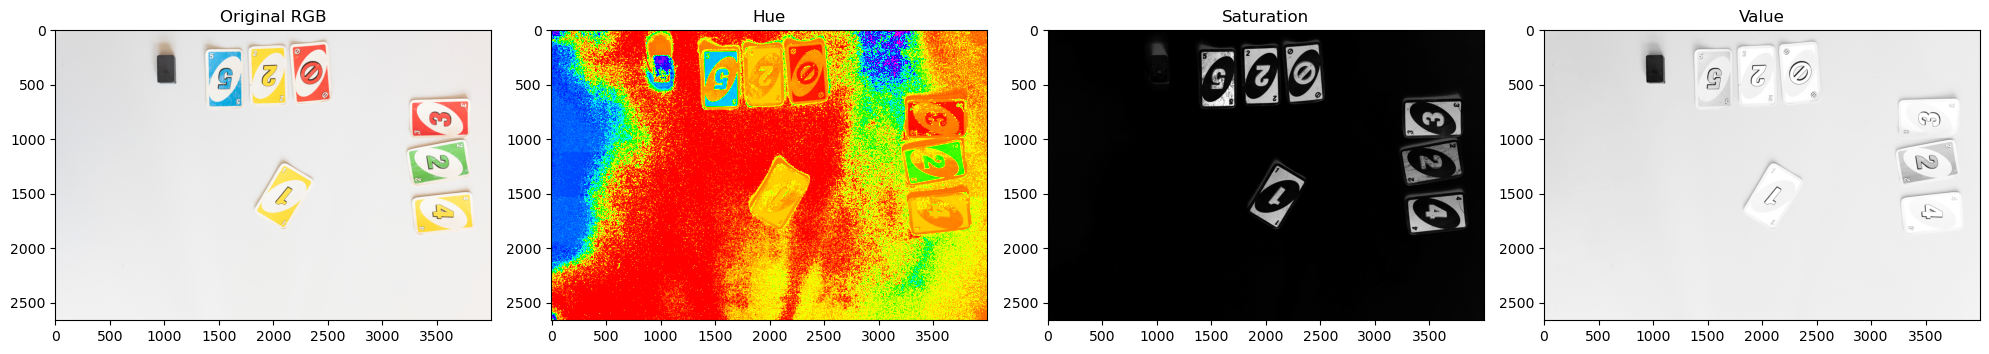

Label: {'image_id': 'L1000770', 'center_card': 'y_1', 'active_player': 'p3', 'player_1_cards': 'EMPTY'}


In [10]:
#looking at first image in detail (HSV channels, like Lab 1)
sample_path = os.path.join(train_image_dir, train_df['image_id'].iloc[0] + '.jpg')
img = np.array(Image.open(sample_path))
img_hsv = rgb2hsv(img)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img)
axes[0].set_title('Original RGB')
axes[1].imshow(img_hsv[:,:,0], cmap='hsv')
axes[1].set_title('Hue')
axes[2].imshow(img_hsv[:,:,1], cmap='gray')
axes[2].set_title('Saturation')
axes[3].imshow(img_hsv[:,:,2], cmap='gray')
axes[3].set_title('Value')

plt.tight_layout()
plt.show()

print("Label:", train_df.iloc[0][["image_id",'center_card','active_player','player_1_cards']].to_dict())

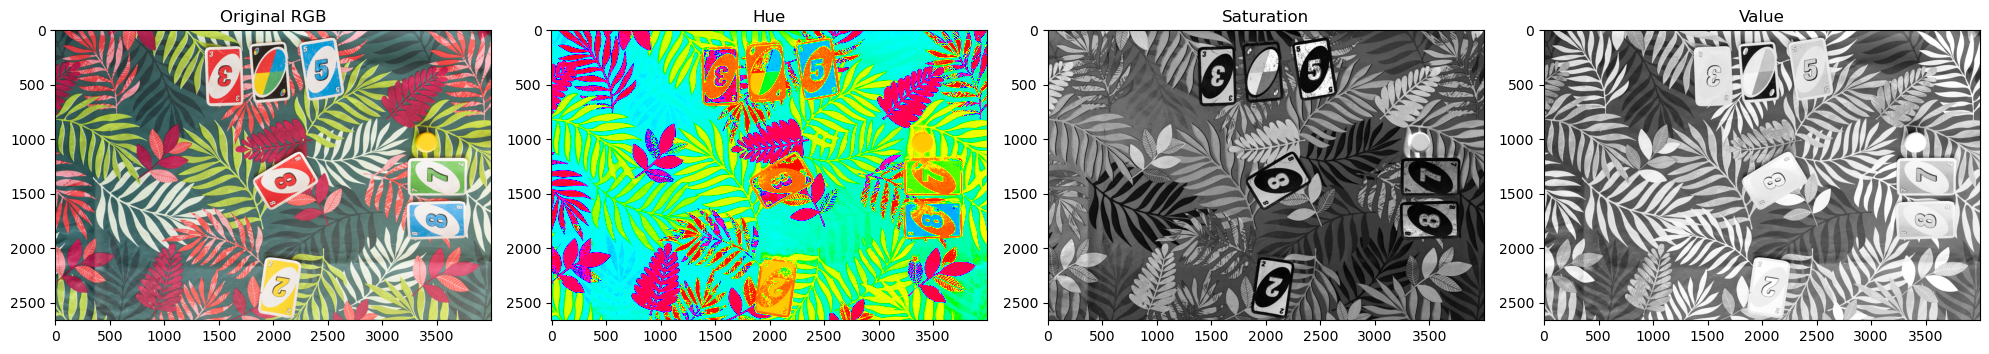

Label: {'center_card': 'r_8', 'active_player': 'p2', 'player_1_cards': 'y_2', 'player_2_cards': 'b_8;g_7', 'player_3_cards': 'r_3;wild;b_5', 'player_4_cards': 'EMPTY'}


In [11]:
#now on a noisy background image  L1000902

sample_path = os.path.join(train_image_dir, 'L1000902' + '.jpg')
img = np.array(Image.open(sample_path))
img_hsv = rgb2hsv(img)

fig, axes = plt.subplots(1, 4, figsize=(20, 5))
axes[0].imshow(img)
axes[0].set_title('Original RGB')
axes[1].imshow(img_hsv[:,:,0], cmap='hsv')
axes[1].set_title('Hue')
axes[2].imshow(img_hsv[:,:,1], cmap='gray')
axes[2].set_title('Saturation')
axes[3].imshow(img_hsv[:,:,2], cmap='gray')
axes[3].set_title('Value')

plt.tight_layout()
plt.show()

# Find and print its label
row = train_df[train_df['image_id'] == 'L1000902']
if not row.empty:
    print("Label:", row[['center_card','active_player','player_1_cards','player_2_cards','player_3_cards','player_4_cards']].to_dict('records')[0])
else:
    print("L1000902 not found in train set — it may be in the test set")

## The takeaway here is, to segment the cards we can characterize them by : 
1. High VALUE threshold → finds the white parts of cards (works on both backgrounds)
2. Find rectangular contours in that mask → cards are rectangles, leaves are not
3. Filter by aspect ratio + minimum area → keep only card-shaped regions

# Segmentation

In [14]:
#loading both the white background and noisy background images for comparison
img_white = np.array(Image.open('train_images/L1000770.jpg'))
img_noisy = np.array(Image.open('train_images/L1000902.jpg'))


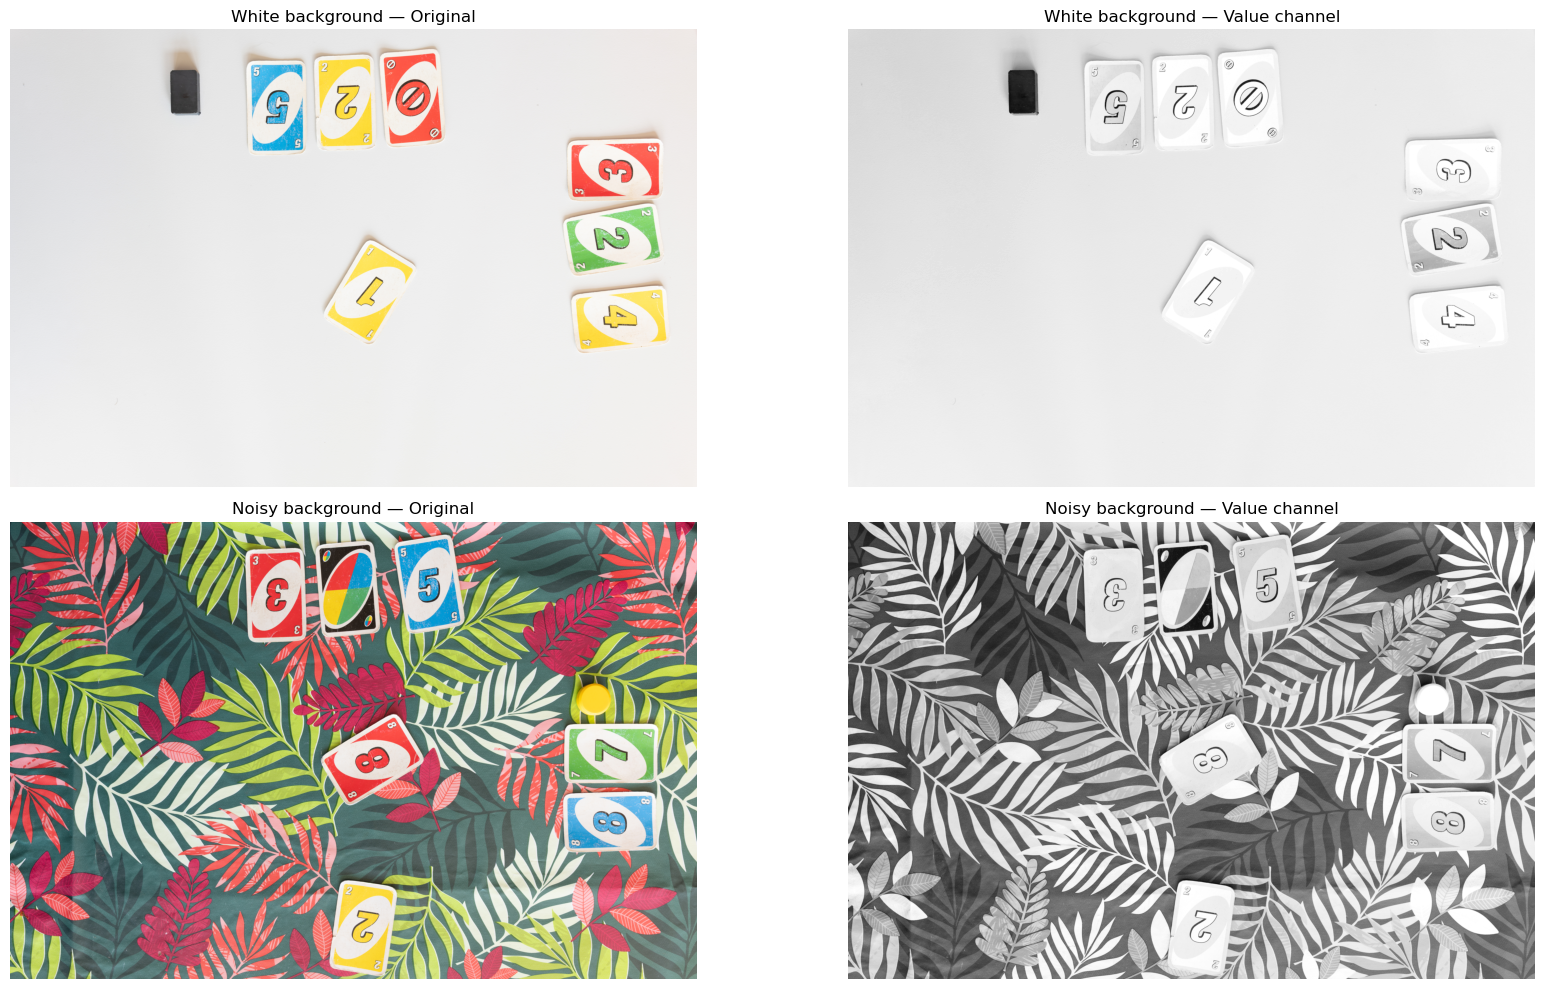

In [ ]:
#compute the value channel for both images
img_white_hsv = rgb2hsv(img_white)
img_noisy_hsv = rgb2hsv(img_noisy)

V_white = img_white_hsv[:, :, 2]
V_noisy = img_noisy_hsv[:, :, 2]

fig, axes = plt.subplots(2, 2, figsize=(18, 10))

axes[0, 0].imshow(img_white)
axes[0, 0].set_title('White background — Original')
axes[0, 0].axis('off')

axes[0, 1].imshow(V_white, cmap='gray')
axes[0, 1].set_title('White background — Value channel')
axes[0, 1].axis('off')

axes[1, 0].imshow(img_noisy)
axes[1, 0].set_title('Noisy background — Original')
axes[1, 0].axis('off')

axes[1, 1].imshow(V_noisy, cmap='gray')
axes[1, 1].set_title('Noisy background — Value channel')
axes[1, 1].axis('off')

plt.tight_layout()
plt.show()

The value-based method is not enough to discern the cards both images. In the noisy background image, we can see that some leaves are equally bright as the cards. We must look into other methods, or a combination of multiple HSV methods.


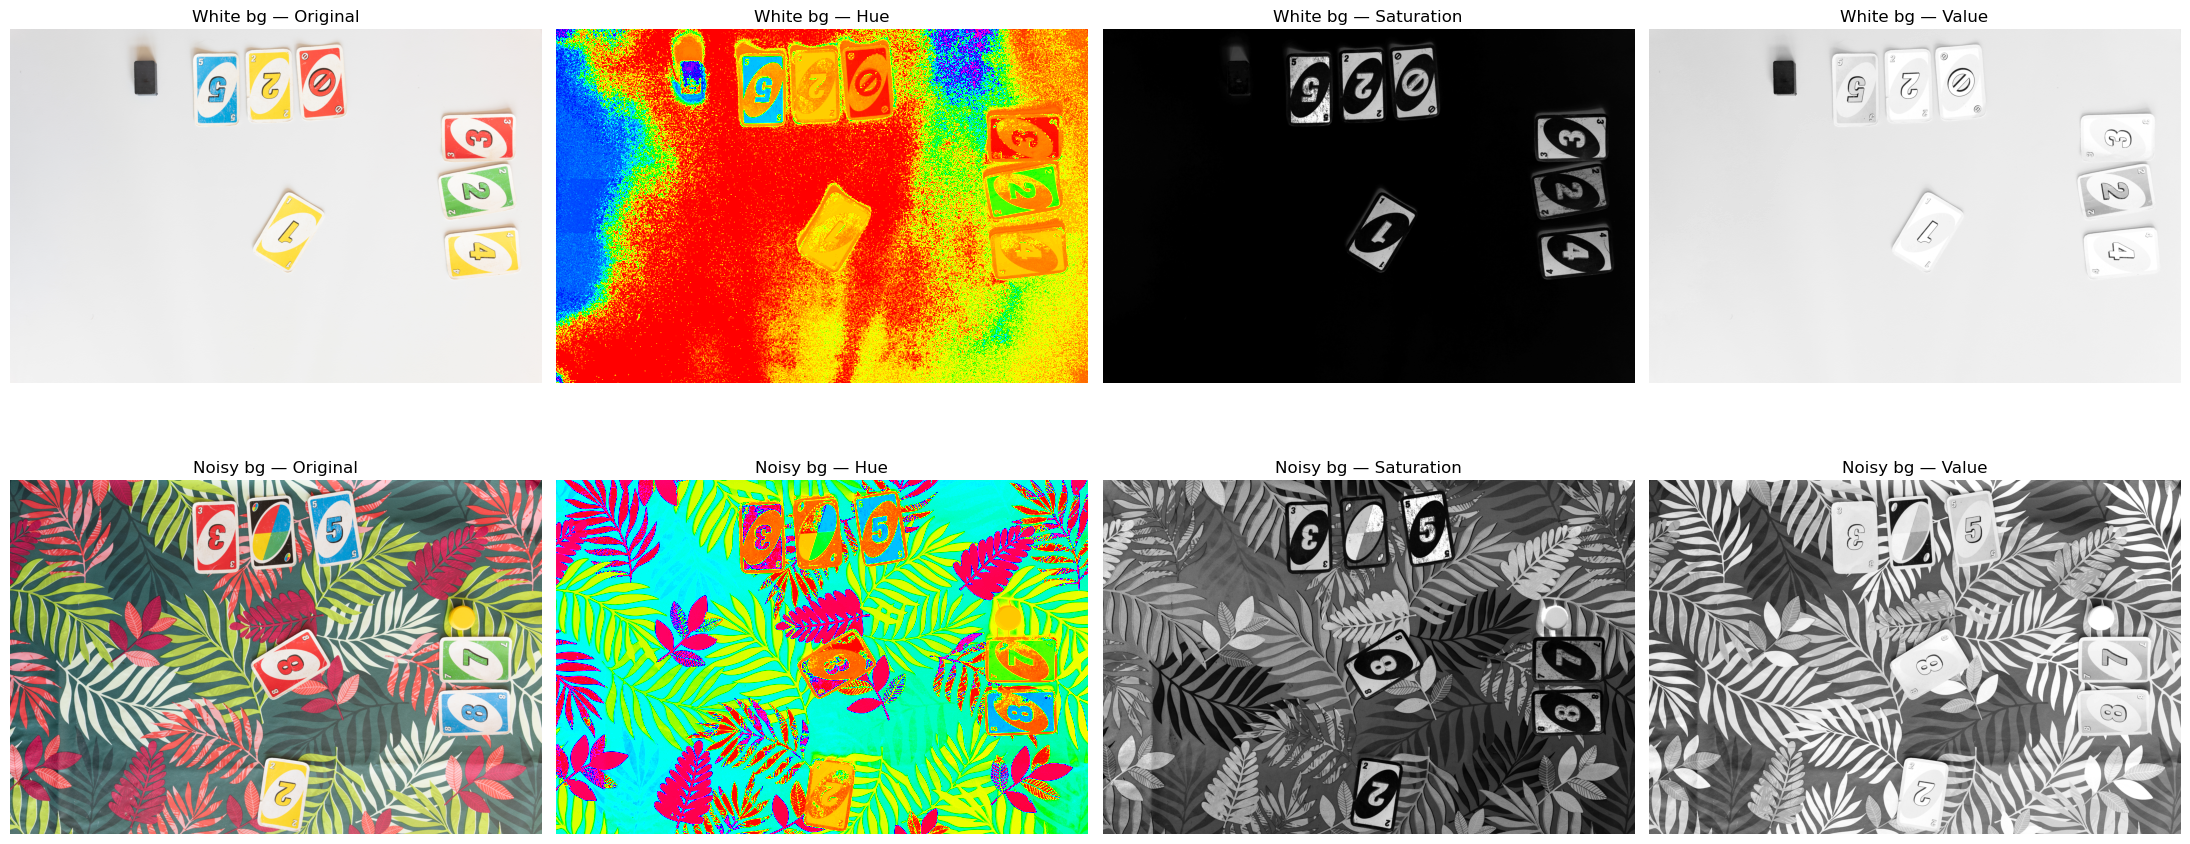

In [17]:
# comparing all HSV channels on both images
fig, axes = plt.subplots(2, 4, figsize=(22, 10))

for row_idx, (img, img_hsv, label) in enumerate([
    (img_white, img_white_hsv, 'White bg'),
    (img_noisy, img_noisy_hsv, 'Noisy bg')
]):
    axes[row_idx, 0].imshow(img)
    axes[row_idx, 0].set_title(f'{label} — Original')
    axes[row_idx, 0].axis('off')

    axes[row_idx, 1].imshow(img_hsv[:,:,0], cmap='hsv')
    axes[row_idx, 1].set_title(f'{label} — Hue')
    axes[row_idx, 1].axis('off')

    axes[row_idx, 2].imshow(img_hsv[:,:,1], cmap='gray')
    axes[row_idx, 2].set_title(f'{label} — Saturation')
    axes[row_idx, 2].axis('off')

    axes[row_idx, 3].imshow(img_hsv[:,:,2], cmap='gray')
    axes[row_idx, 3].set_title(f'{label} — Value')
    axes[row_idx, 3].axis('off')

plt.tight_layout()
plt.show()

Here, we notice the following : 
1. For a white background, a saturation-based method is a clear winner ! Cards are bright while the background is dark.
2. For a noisy background, cards are low saturation islands surrounded by high saturation background. This is the opposite as the white background example.
   
White background → cards have high saturation

Noisy background → cards have lower saturation than background (but still visible as distinct regions)